In [1]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
# =========================================
# 2. LOAD DATA
# =========================================
data = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Initial Shape:", data.shape)

Initial Shape: (7043, 21)


In [4]:

# =========================================
# 3. PREPROCESSING
# =========================================
data.drop("customerID", axis=1, inplace=True)

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)

data["Churn"] = data["Churn"].map({"Yes":1, "No":0})

data = pd.get_dummies(data, drop_first=True)

/tmp/ipykernel_3330/2435805073.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)


In [5]:
# =========================================
# 4. FEATURE ENGINEERING
# =========================================
data["AvgCharges"] = data["TotalCharges"] / (data["tenure"] + 1)
data["HighValueCustomer"] = (data["MonthlyCharges"] > data["MonthlyCharges"].median()).astype(int)

In [6]:



# =========================================
# 5. SPLIT DATA
# =========================================
X = data.drop("Churn", axis=1)
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
# =========================================
# 6. SCALING
# =========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# =========================================
# 7. SMOTE (BALANCING)
# =========================================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", np.bincount(y_train_smote))

After SMOTE: [4139 4139]


In [9]:
# =========================================
# 8. MODEL TRAINING
# =========================================
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
gb = GradientBoostingClassifier(random_state=42)

rf.fit(X_train_smote, y_train_smote)
xgb.fit(X_train_smote, y_train_smote)
gb.fit(X_train_smote, y_train_smote)

GradientBoostingClassifier(random_state=42)

In [10]:

# =========================================
# 9. VOTING MODEL
# =========================================
voting_model = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('gb', gb)],
    voting='soft'
)

voting_model.fit(X_train_smote, y_train_smote)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=10,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42))],
                 voting='soft')

In [11]:


# =========================================
# 10. EVALUATION FUNCTION
# =========================================
def evaluate(model, X_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

    return y_pred, y_prob

# Evaluate models
y_pred_rf, y_prob_rf = evaluate(rf, X_test_scaled, "Random Forest")
y_pred_xgb, y_prob_xgb = evaluate(xgb, X_test_scaled, "XGBoost")
y_pred_vote, y_prob_vote = evaluate(voting_model, X_test_scaled, "Voting Model")


Random Forest
Accuracy: 0.7629524485450674
ROC-AUC: 0.8412333049161693
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409


XGBoost
Accuracy: 0.7771469127040455
ROC-AUC: 0.8156203983569713
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.58      0.61      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409


Voting Model
Accuracy: 0.7679205110007097
ROC-AUC: 0.8386899687411197
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.55     

In [12]:
# =========================================
# 11. CROSS VALIDATION
# =========================================
cv_score = cross_val_score(xgb, X_train_smote, y_train_smote, cv=5, scoring='roc_auc')
print("\nCross Validation ROC-AUC:", cv_score.mean())


Cross Validation ROC-AUC: 0.9353030555501232


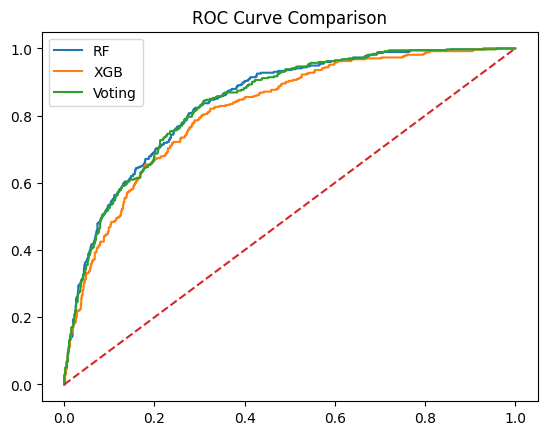

In [13]:


# =========================================
# 12. ROC CURVE
# =========================================
plt.figure()
for probs, name in [(y_prob_rf,"RF"), (y_prob_xgb,"XGB"), (y_prob_vote,"Voting")]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

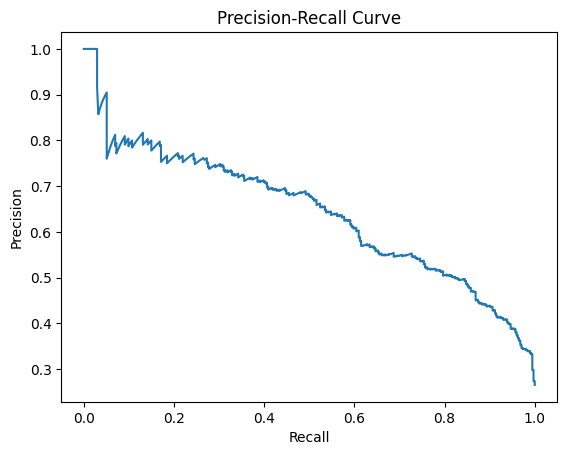

In [14]:

# =========================================
# 13. PRECISION-RECALL CURVE
# =========================================
precision, recall, _ = precision_recall_curve(y_test, y_prob_vote)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

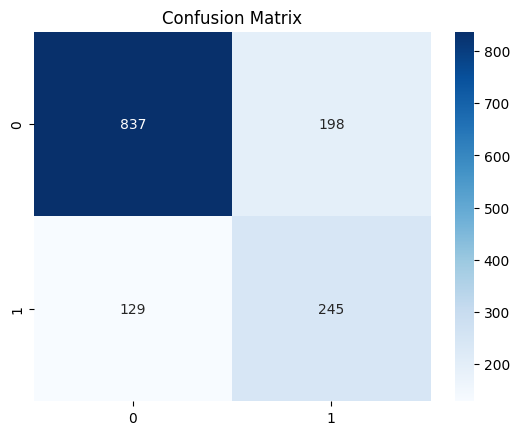

In [15]:
# =========================================
# 14. CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_test, y_pred_vote)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

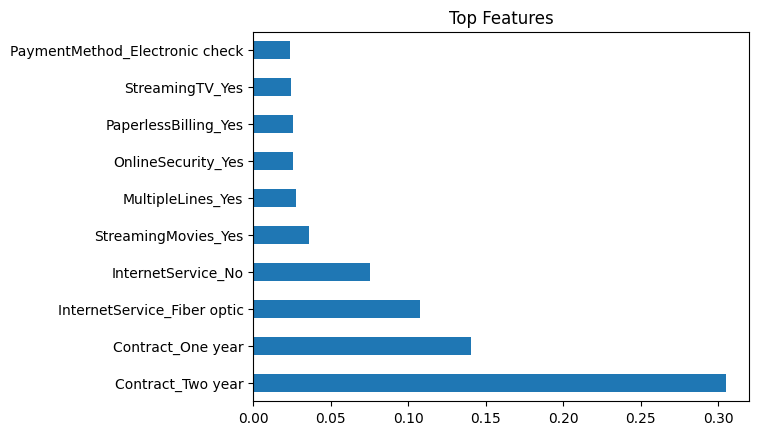

In [16]:
# =========================================
# 15. FEATURE IMPORTANCE
# =========================================
feat_importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

feat_importance.head(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

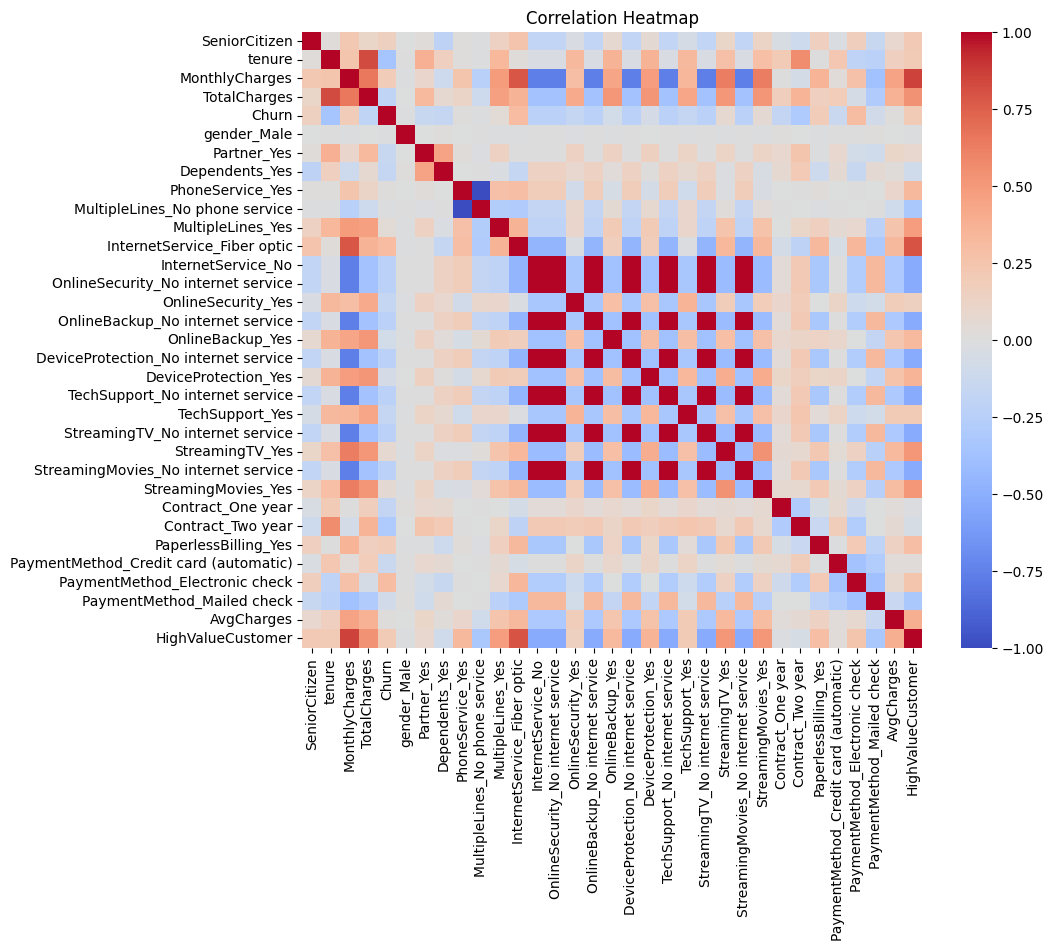

In [17]:

# =========================================
# 16. CORRELATION HEATMAP
# =========================================
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# =========================================
# 17. THRESHOLD TUNING
# =========================================
threshold = 0.4
y_pred_custom = (y_prob_vote > threshold).astype(int)

print("\nCustom Threshold Report:")
print(classification_report(y_test, y_pred_custom))


Custom Threshold Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409




Customer Segmentation:
Low Risk       782
Medium Risk    394
High Risk      233
Name: count, dtype: int64


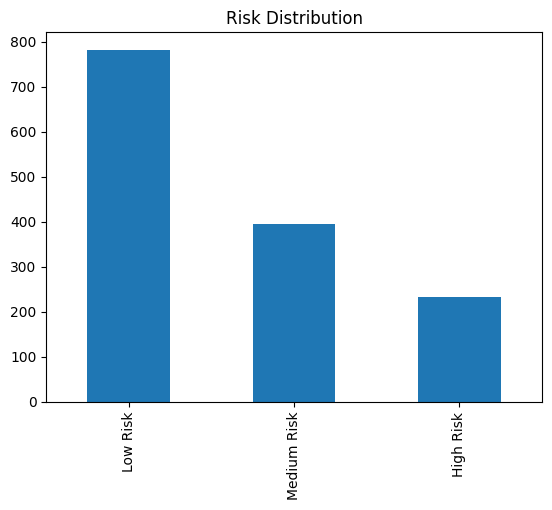

In [19]:

# =========================================
# 18. CUSTOMER SEGMENTATION
# =========================================
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_labels = [risk_category(p) for p in y_prob_vote]
risk_counts = pd.Series(risk_labels).value_counts()

print("\nCustomer Segmentation:")
print(risk_counts)

risk_counts.plot(kind='bar')
plt.title("Risk Distribution")
plt.show()

In [20]:
# =========================================
# 19. HIGH-RISK CUSTOMERS
# =========================================
high_risk_data = X_test.copy()
high_risk_data["Churn_Prob"] = y_prob_vote

top_customers = high_risk_data.sort_values(by="Churn_Prob", ascending=False).head(5)

print("\nTop 5 High-Risk Customers:")
print(top_customers)


Top 5 High-Risk Customers:
      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
6623              1       1           76.45         76.45         True   
4585              1       1           85.05         85.05        False   
2464              0       1           77.15         77.15        False   
1731              1       1           69.60         69.60        False   
6866              0       1           95.45         95.45         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
6623        False           False              True   
4585        False           False              True   
2464        False           False              True   
1731        False           False              True   
6866        False           False              True   

      MultipleLines_No phone service  MultipleLines_Yes  ...  \
6623                           False               True  ...   
4585                           False               True  ...   
2464

In [21]:
# =========================================
# 20. COST ANALYSIS
# =========================================
tn, fp, fn, tp = cm.ravel()

cost_fn = 5000
cost_fp = 1000

total_cost = (fn * cost_fn) + (fp * cost_fp)
print("\nTotal Cost:", total_cost)


Total Cost: 843000


In [22]:
# =========================================
# 21. ANN MODEL
# =========================================
ann = Sequential([
    Dense(64, activation='relu', input_dim=X_train_smote.shape[1]),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train_smote, y_train_smote, epochs=10, batch_size=32, verbose=0)

y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [23]:

# =========================================
# 22. MODEL COMPARISON TABLE
# =========================================
rf_roc = roc_auc_score(y_test, y_prob_rf)
xgb_roc = roc_auc_score(y_test, y_prob_xgb)
vote_roc = roc_auc_score(y_test, y_prob_vote)

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Voting"],
    "ROC-AUC": [rf_roc, xgb_roc, vote_roc]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
           Model   ROC-AUC
0  Random Forest  0.841233
1        XGBoost  0.815620
2         Voting  0.838690


In [24]:
# =========================================
# 23. SAVE MODEL
# =========================================
pickle.dump(voting_model, open("final_model.pkl", "wb"))


Generating SHAP explanations...


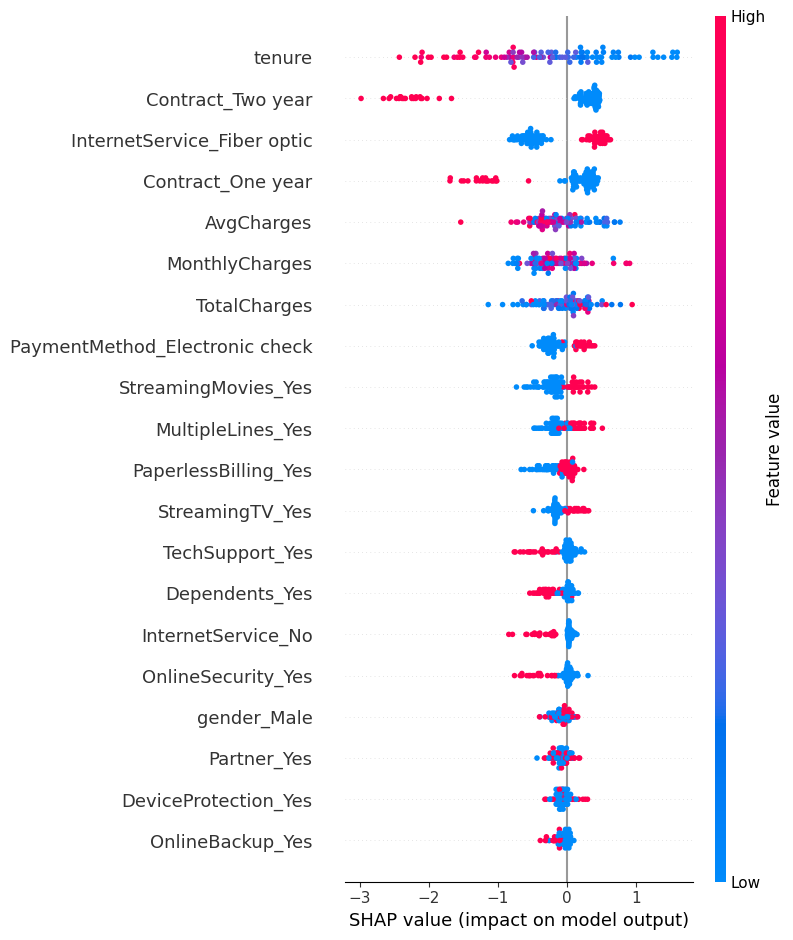

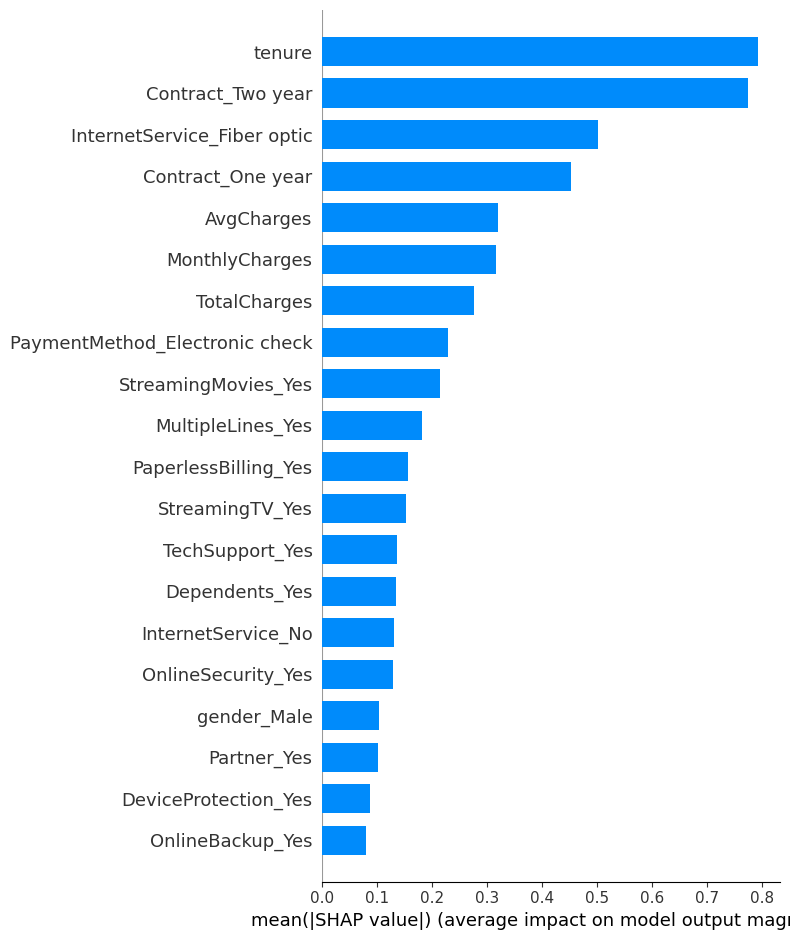

In [27]:
# =========================================
# 24. SHAP EXPLAINABILITY (FINAL ADDITION ⭐)
# =========================================
import shap

print("\nGenerating SHAP explanations...")

# Use TreeExplainer for XGBoost (faster & better)
explainer = shap.TreeExplainer(xgb)

# Take small sample (for speed)
X_sample = X_test_scaled[:100]

shap_values = explainer.shap_values(X_sample)

# Summary Plot (Global Explanation)
shap.summary_plot(shap_values, X_test.iloc[:100])

# Bar Plot (Feature Importance)
shap.summary_plot(shap_values, X_test.iloc[:100], plot_type="bar")

In [28]:
# =========================================
# 25. FINAL OUTCOME (WITH REASONS)
# =========================================
print("\n================ FINAL OUTCOME ================\n")

best_model = results.loc[results["ROC-AUC"].idxmax(), "Model"]
print("Best Model:", best_model)

print("\nModel Performance:")
print(results)

print("\nTop Features Influencing Churn:")
print(feat_importance.head(5))

print("\nCustomer Risk Distribution:")
print(risk_counts)

print("\nTotal Cost Impact:", total_cost)

print("\nSample Predictions:")
for i in range(5):
    print(f"Customer {i+1}: {y_prob_vote[i]:.2f} → {'Churn' if y_prob_vote[i]>0.5 else 'No Churn'}")

print("\nKey Reasons for Churn:")
for feature in feat_importance.head(5).index:
    print(f"- {feature} plays a major role in predicting churn")
print("\nExplainability: SHAP used to interpret feature impact on predictions")

ann_acc = accuracy_score(y_test, y_pred_ann)
vote_acc = accuracy_score(y_test, y_pred_vote)

print("\nAccuracy Comparison:")
print(f"Voting Model: {vote_acc:.4f}")
print(f"ANN Model   : {ann_acc:.4f}")


================ FINAL OUTCOME ================

Best Model: Random Forest

Model Performance:
           Model   ROC-AUC
0  Random Forest  0.841233
1        XGBoost  0.815620
2         Voting  0.838690

Top Features Influencing Churn:
Contract_Two year              0.304809
Contract_One year              0.140336
InternetService_Fiber optic    0.107742
InternetService_No             0.075632
StreamingMovies_Yes            0.036053
dtype: float32

Customer Risk Distribution:
Low Risk       782
Medium Risk    394
High Risk      233
Name: count, dtype: int64

Total Cost Impact: 843000

Sample Predictions:
Customer 1: 0.02 → No Churn
Customer 2: 0.87 → Churn
Customer 3: 0.08 → No Churn
Customer 4: 0.42 → No Churn
Customer 5: 0.02 → No Churn

Key Reasons for Churn:
- Contract_Two year plays a major role in predicting churn
- Contract_One year plays a major role in predicting churn
- InternetService_Fiber optic plays a major role in predicting churn
- InternetService_No plays a major role 